## Support Vector Machines

SVM is an exciting algorithm and the concepts are relatively simple. The classifier separates data points  
using a hyperplane with the largest amount of margin. That's why an SVM classifier is also known as a discriminative classifier.  
SVM finds an optimal hyperplane which helps in classifying new data points.

**Support Vectors**
Support vectors are the data points, which are closest to the hyperplane. These points will define the separating line better by   calculating margins. These points are more relevant to the construction of the classifier.  
 
**Hyperplane**  
A hyperplane is a decision plane which separates between a set of objects having different class memberships.  
  
**Margin**  
A margin is a gap between the two lines on the closest class points. This is calculated as the perpendicular distance from the line to   support vectors or closest points. If the margin is larger in between the classes, then it is considered a good margin, a smaller margin   is a bad margin.  

**How does SVM work?**  
The main objective is to segregate the given dataset in the best possible way. The distance between the either nearest points  
is known as the margin. The objective is to select a hyperplane with the maximum possible margin between support vectors in the given   dataset. SVM searches for the maximum marginal hyperplane in the following steps:    

Generate hyperplanes which segregates the classes in the best way. Left-hand side figure showing three hyperplanes black,  
blue and orange. Here, the blue and orange have higher classification error, but the black is separating the two classes correctly.    

Select the right hyperplane with the maximum segregation from the either nearest data points as shown in the right-hand side figure.  

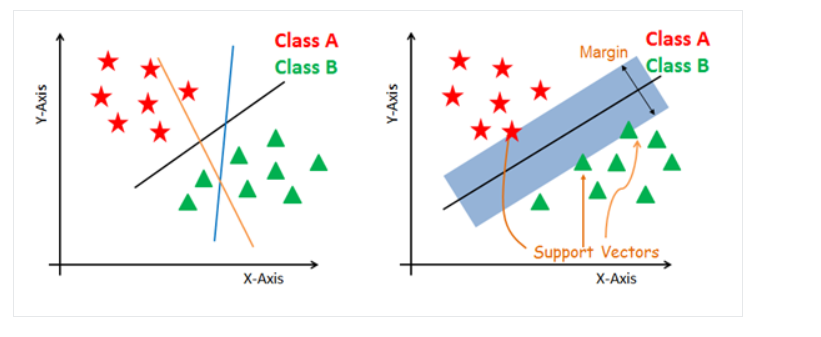

**Dealing with non-linear and inseparable planes**    
Some problems can’t be solved using linear hyperplane, as shown in the figure below (left-hand side).  

In such situation, SVM uses a kernel trick to transform the input space to a higher dimensional space as shown on the right. The data   points are plotted on the x-axis and z-axis (Z is the squared sum of both x and y: z=x^2=y^2). Now you can easily segregate these points   using linear separation.

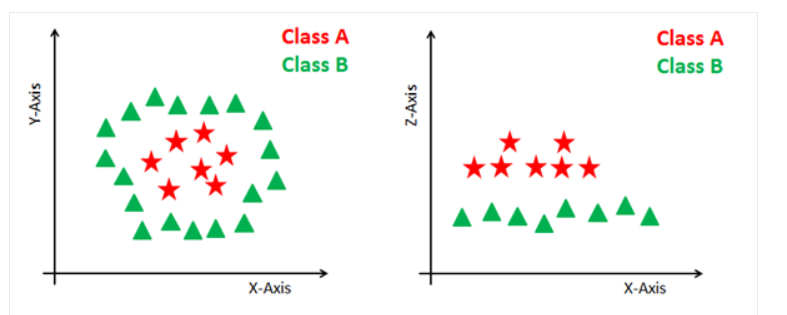

**SVM Kernels**  
The SVM algorithm is implemented in practice using a kernel. A kernel transforms an input data space into the required form.   
SVM uses a technique called the kernel trick. Here, the kernel takes a low-dimensional input space and transforms   
it into a higher   dimensional space. In other words, you can say that it converts nonseparable problem to separable   
problems by adding more dimension to it. It is most useful in non-linear separation problem. Kernel trick helps you to build a more   accurate classifier.

In [1]:
#Import scikit-learn dataset library
from sklearn import datasets

#Load dataset
cancer = datasets.load_breast_cancer()


In [2]:
# print the names of the 13 features
print("Features: ", cancer.feature_names)

# print the label type of cancer('malignant' 'benign')
print("Labels: ", cancer.target_names)


Features:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Labels:  ['malignant' 'benign']


In [3]:
# print data(feature)shape
cancer.data.shape


(569, 30)

In [4]:
# print the cancer labels (0:malignant, 1:benign)
print(cancer.target)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

In [5]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.3,random_state=109) # 70% training and 30% test


In [6]:
#Import svm model
from sklearn import svm

#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)


In [7]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy: how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.9649122807017544


In [8]:
# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(y_test, y_pred))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(y_test, y_pred))


Precision: 0.9811320754716981
Recall: 0.9629629629629629
